<a href="https://colab.research.google.com/github/so-yeon-hwang/DataSciencePractice/blob/main/DecisionTreesScikitlearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Classification on Breast Cancer Dataset

This project demonstrates how to build and evaluate a **Decision Tree Classifier** using the Breast Cancer dataset from `sklearn`.  The model uses the Gini index as a criterion to measure node impurity during training, determining how the data is split at each decision point.
It covers the complete machine learning workflow — from **data preprocessing, train/test splitting, model training, evaluation,** to **feature importance analysis**.

The goal is to understand how model parameters like `max_depth` affect performance and interpret the classification metrics such as **accuracy, precision, recall,** and **f1-score**.

Libraries used: `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`.

#1. Import Data

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [4]:
data =load_breast_cancer()
dataset = pd.DataFrame(data = data['data'], columns = data['feature_names'])
dataset.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [5]:
dataset.size

17070

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#2. Train

## 2-1. Split Dataset into Train/Test

Reference Material :  
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

In [12]:
from sklearn.model_selection import train_test_split
X = dataset.copy()
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [30]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier() # Generate a new object / classifier model
clf = clf.fit(X_train, y_train) # Training the object classifier

In [31]:
clf.get_params()

## critierion of the impurity : gini
## gini : (for all category) 1-pi^2

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [20]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [19]:
X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
162,19.59,18.15,130.70,1214.0,0.11200,0.16660,0.250800,0.12860,0.2027,0.06082,...,26.73,26.39,174.90,2232.0,0.1438,0.3846,0.68100,0.22470,0.3643,0.09223
434,14.86,16.94,94.89,673.7,0.08924,0.07074,0.033460,0.02877,0.1573,0.05703,...,16.31,20.54,102.30,777.5,0.1218,0.1550,0.12200,0.07971,0.2525,0.06827
20,13.08,15.71,85.63,520.0,0.10750,0.12700,0.045680,0.03110,0.1967,0.06811,...,14.50,20.49,96.09,630.5,0.1312,0.2776,0.18900,0.07283,0.3184,0.08183
261,17.35,23.06,111.00,933.1,0.08662,0.06290,0.028910,0.02837,0.1564,0.05307,...,19.85,31.47,128.20,1218.0,0.1240,0.1486,0.12110,0.08235,0.2452,0.06515
242,11.30,18.19,73.93,389.4,0.09592,0.13250,0.154800,0.02854,0.2054,0.07669,...,12.58,27.96,87.16,472.9,0.1347,0.4848,0.74360,0.12180,0.3308,0.12970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,11.99,24.89,77.61,441.3,0.10300,0.09218,0.054410,0.04274,0.1820,0.06850,...,12.98,30.36,84.48,513.9,0.1311,0.1822,0.16090,0.12020,0.2599,0.08251
226,10.44,15.46,66.62,329.6,0.10530,0.07722,0.006643,0.01216,0.1788,0.06450,...,11.52,19.80,73.47,395.4,0.1341,0.1153,0.02639,0.04464,0.2615,0.08269
552,12.77,29.43,81.35,507.9,0.08276,0.04234,0.019970,0.01499,0.1539,0.05637,...,13.87,36.00,88.10,594.7,0.1234,0.1064,0.08653,0.06498,0.2407,0.06484
193,12.34,26.86,81.15,477.4,0.10340,0.13530,0.108500,0.04562,0.1943,0.06937,...,15.65,39.34,101.70,768.9,0.1785,0.4706,0.44250,0.14590,0.3215,0.12050


In [18]:
X_test

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
53,18.22,18.70,120.30,1033.0,0.11480,0.14850,0.177200,0.106000,0.2092,0.06310,...,20.60,24.13,135.10,1321.0,0.12800,0.22970,0.26230,0.13250,0.3021,0.07987
137,11.43,15.39,73.06,399.8,0.09639,0.06889,0.035030,0.028750,0.1734,0.05865,...,12.32,22.02,79.93,462.0,0.11900,0.16480,0.13990,0.08476,0.2676,0.06765
262,17.29,22.13,114.40,947.8,0.08999,0.12730,0.096970,0.075070,0.2108,0.05464,...,20.39,27.24,137.90,1295.0,0.11340,0.28670,0.22980,0.15280,0.3067,0.07484
31,11.84,18.70,77.93,440.6,0.11090,0.15160,0.121800,0.051820,0.2301,0.07799,...,16.82,28.12,119.40,888.7,0.16370,0.57750,0.69560,0.15460,0.4761,0.14020
42,19.07,24.81,128.30,1104.0,0.09081,0.21900,0.210700,0.099610,0.2310,0.06343,...,24.09,33.17,177.40,1651.0,0.12470,0.74440,0.72420,0.24930,0.4670,0.10380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,13.50,12.71,85.69,566.2,0.07376,0.03614,0.002758,0.004419,0.1365,0.05335,...,14.97,16.94,95.48,698.7,0.09023,0.05836,0.01379,0.02210,0.2267,0.06192
98,11.60,12.84,74.34,412.6,0.08983,0.07525,0.041960,0.033500,0.1620,0.06582,...,13.06,17.16,82.96,512.5,0.14310,0.18510,0.19220,0.08449,0.2772,0.08756
523,13.71,18.68,88.73,571.0,0.09916,0.10700,0.053850,0.037830,0.1714,0.06843,...,15.11,25.63,99.43,701.9,0.14250,0.25660,0.19350,0.12840,0.2849,0.09031
501,13.82,24.49,92.33,595.9,0.11620,0.16810,0.135700,0.067590,0.2275,0.07237,...,16.01,32.94,106.00,788.0,0.17940,0.39660,0.33810,0.15210,0.3651,0.11830


In [15]:
predictions = clf.predict(X_test)
predictions

array([0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1])

In [32]:
clf.predict_proba(X_test)
# almost binary with 1 and 0
# Let's try the training session with shorter tree, which has max_depth = 4

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.

## 2-2. Experiment : What if the tree is not deep enough?

In [ ]:
# Let's try the training session with shorter tree, which has max_depth = 4

In [22]:
clf = DecisionTreeClassifier(max_depth = 4) # We can limit the depth of the tree by simply putting parameter
clf = clf.fit(X_train, y_train)

In [23]:
clf.get_params() # on 4th line, we can check the max_depth is 4

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 4,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [26]:
predictions = clf.predict(X_test)
predictions # Results are still binary

array([0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1])


> Insight 1.



If we limit the max_depth, we have more possibility to get less accurate prediction results with more uncertainty.

The number used to be binary on first training, but now we have decimal points of number, which means less certainty, which means higher impurity and less homogeneity

In [27]:
clf.predict_proba(X_test)

array([[1.        , 0.        ],
       [0.0077821 , 0.9922179 ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.0077821 , 0.9922179 ],
       [0.        , 1.        ],
       [0.0077821 , 0.9922179 ],
       [0.16666667, 0.83333333],
       [0.66666667, 0.33333333],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.13043478, 0.86956522],
       [0.0077821 , 0.9922179 ],
       [1.        , 0.        ],
       [0.0077821 , 0.9922179 ],
       [0.        , 1.        ],
       [0.0077821 , 0.9922179 ],
       [1.        , 0.        ],
       [0.0077821 , 0.9922179 ],
       [0.0077821 , 0.9922179 ],
       [0.0077821 , 0.9922179 ],
       [0.0077821 , 0.9922179 ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.0077821 , 0.9922179 ],
       [1.        , 0.        ],
       [0.66666667, 0.33333333],
       [0.0077821 , 0.9922179 ],
       [0.

#3. Prediction

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions)

0.9736842105263158

In [34]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions, labels = [0,1])

# actual = 0 | predicted 0 -> 48 | predicted 1 -> 3
# actual = 1 | predicted 1 -> 0 | predicted 63 -> 63

array([[48,  3],
       [ 0, 63]])

In [35]:
from sklearn.metrics import precision_score
precision_score(y_test, predictions)

0.9545454545454546

reference material :

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html

In [37]:
from sklearn.metrics import recall_score
recall_score(y_test, predictions)

1.0

In [38]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions, target_names = ['malignant', 'benign']))

              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        51
      benign       0.95      1.00      0.98        63

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# 3. Feature Importance (Based on Gini Index)

Reference Material :


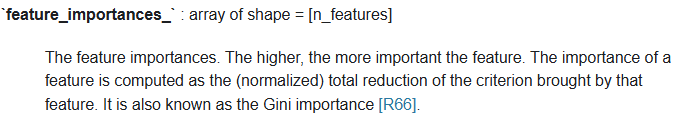



https://scikit-learn.org/0.15/modules/generated/sklearn.tree.DecisionTreeClassifier.html?utm_source=chatgpt.com#r66

In [39]:
# All of the columns
feature_names = X.columns
feature_names

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [40]:
clf.feature_importances_
# Which one(X) affects the most to the result(y)? (Let's check on numeric way)

array([0.        , 0.03458785, 0.        , 0.        , 0.        ,
       0.00728223, 0.        , 0.        , 0.00640836, 0.        ,
       0.        , 0.02654733, 0.        , 0.0146498 , 0.00789914,
       0.01441881, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.02046846, 0.        , 0.69228693, 0.        ,
       0.        , 0.01334614, 0.15409451, 0.00801045, 0.        ])

In [44]:
feature_importance = (
    pd.DataFrame(clf.feature_importances_, index=feature_names, columns=["importance"])
    .sort_values(by="importance", ascending=False)
)
feature_importance

,importance
worst area,0.692287
worst concave points,0.154095
mean texture,0.034588
texture error,0.026547
worst texture,0.020468
area error,0.014650
compactness error,0.014419
worst concavity,0.013346
worst symmetry,0.008010
smoothness error,0.007899


<Axes: >

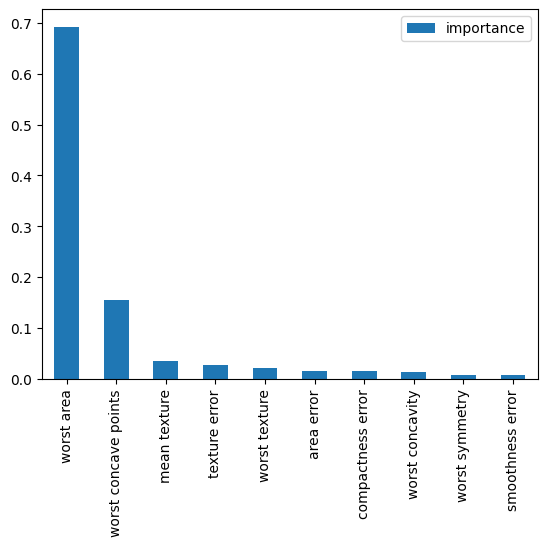

In [45]:
feature_importance.head(10).plot(kind='bar')

# 4. Decision Tree Visualization

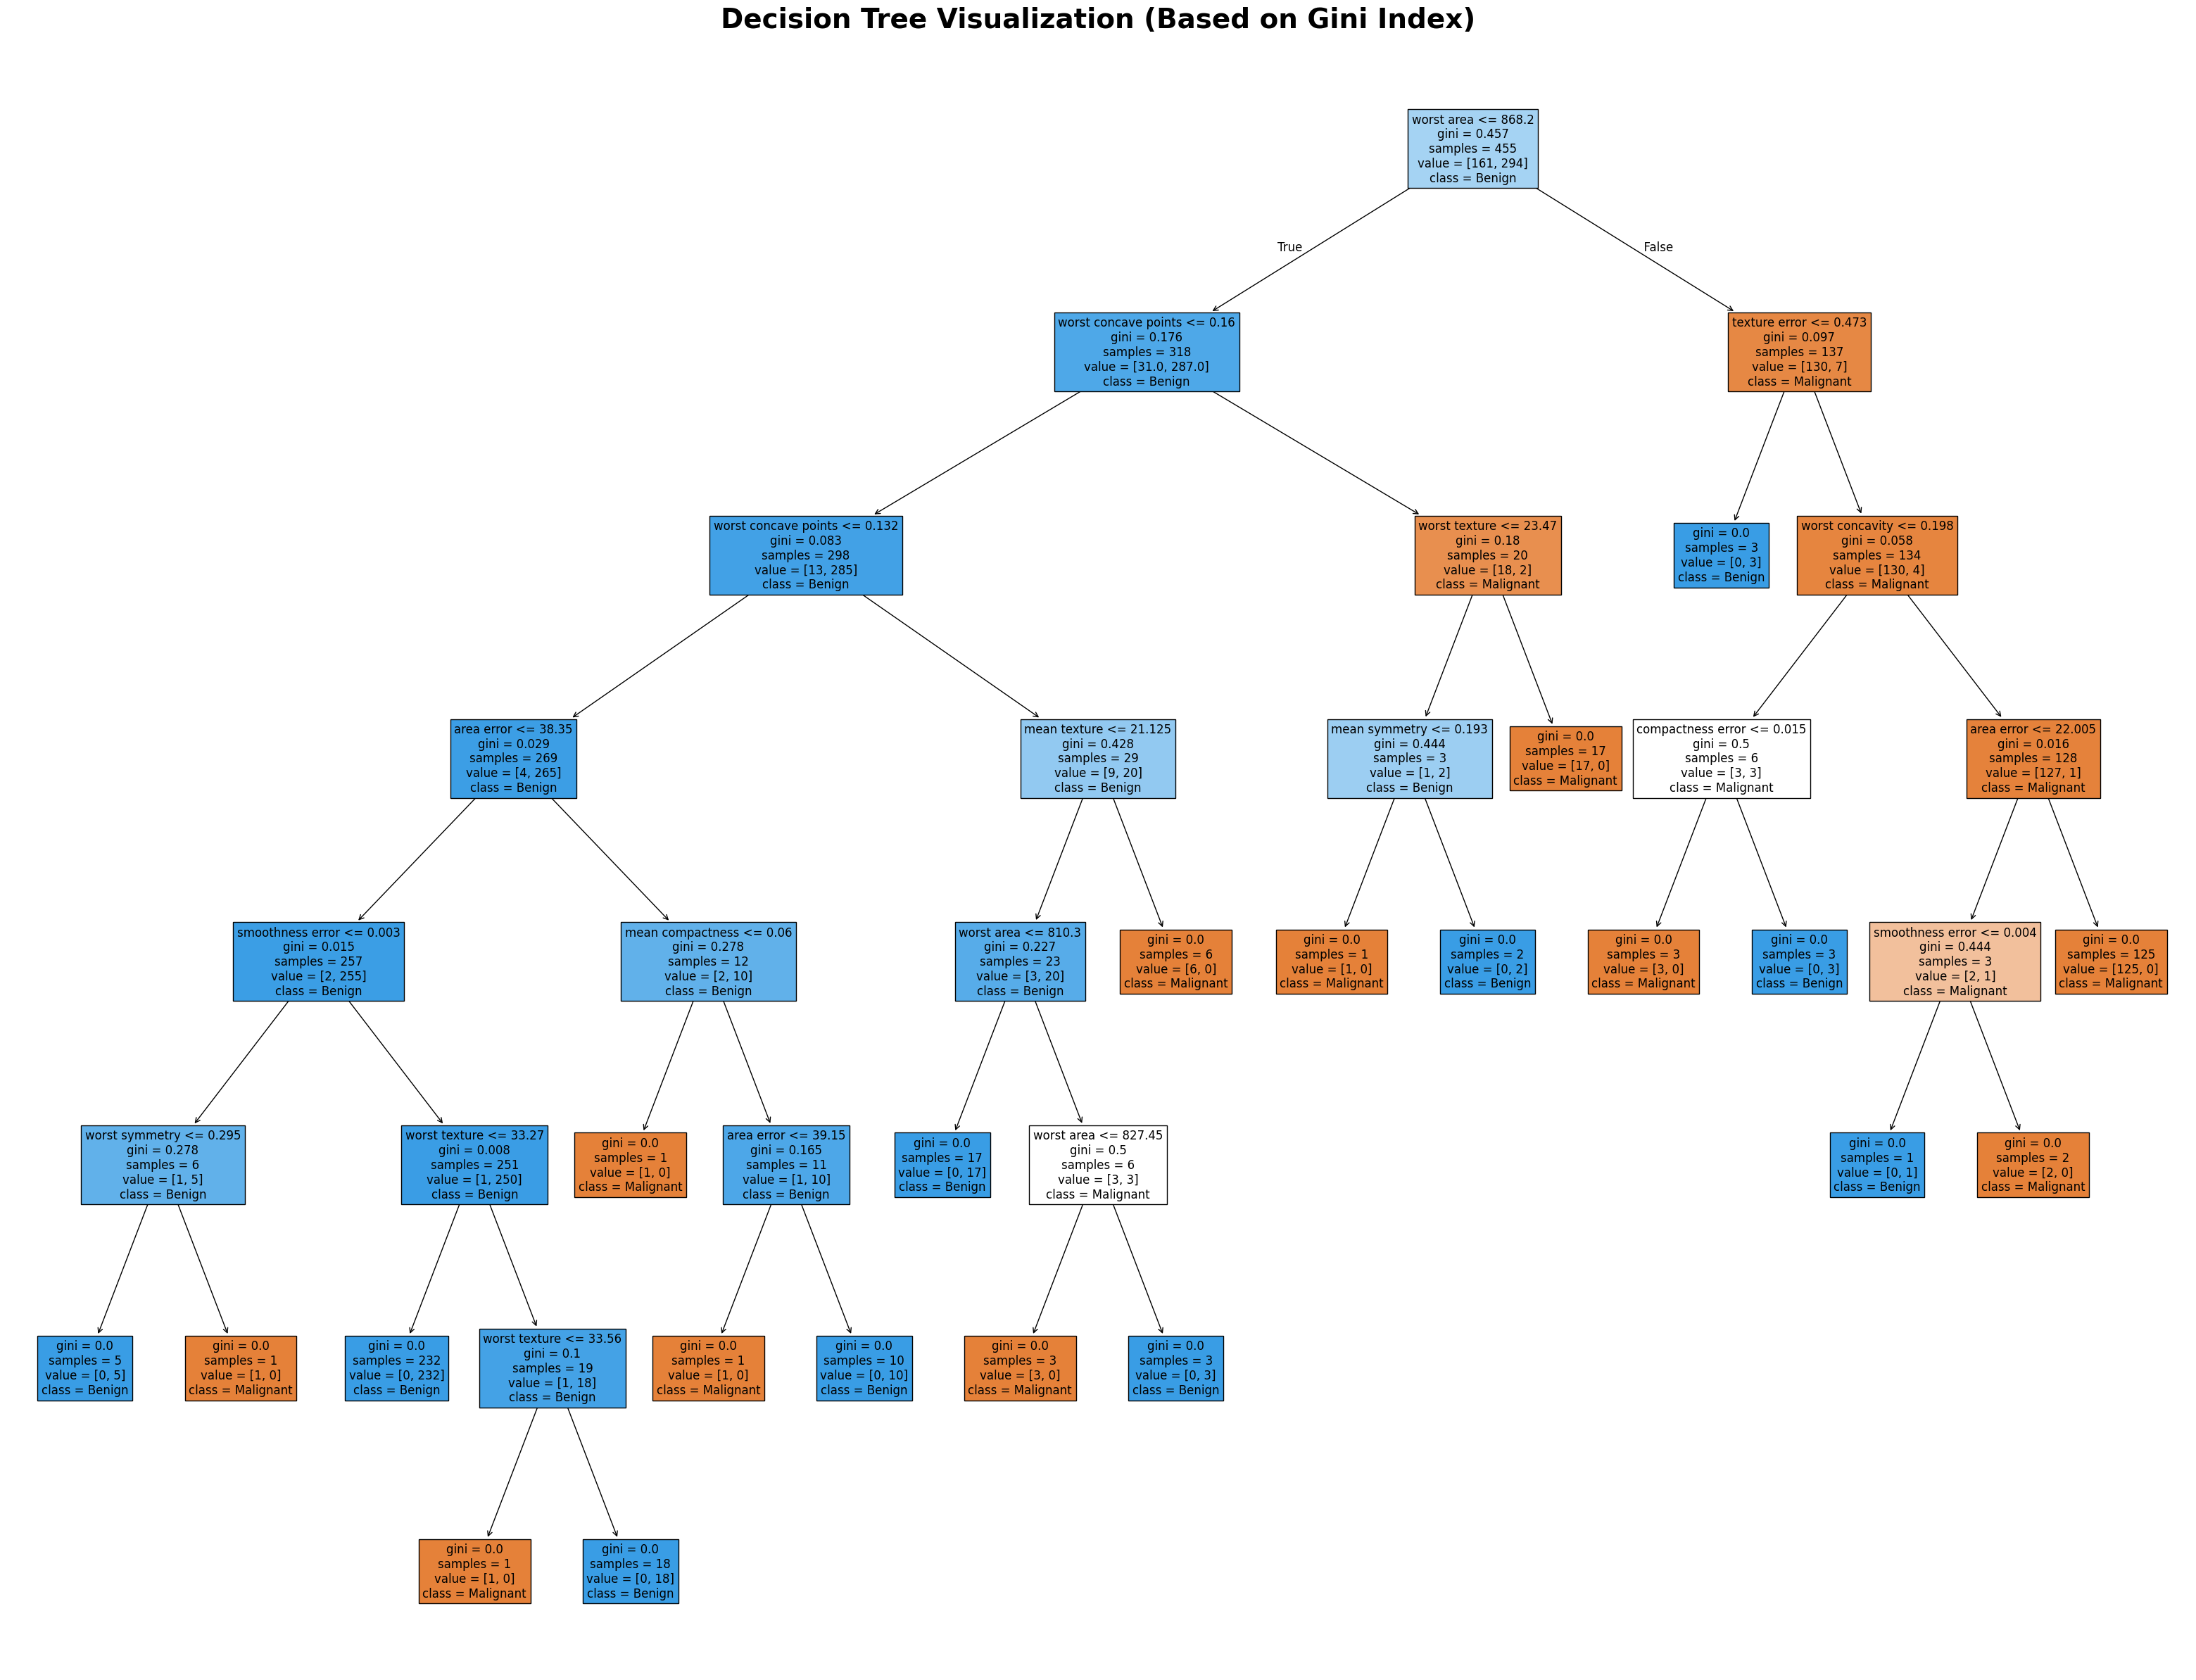

In [55]:
from sklearn import tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(40, 30))
tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names={0: "Malignant", 1: "Benign"},
    filled=True,
    fontsize=12,
    ax=ax
)
ax.set_title("Decision Tree Visualization (Based on Gini Index)", fontsize=28, fontweight='bold', pad=20)
plt.show()



> Insight2.



| Feature Name             | Medical Meaning                                                  | What It Indicates Clinically                                                                                    |
| ------------------------ | ---------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------- |
| **worst area**           | The largest measured size of the tumor                           | A larger tumor area often indicates a higher likelihood of malignancy (cancer).                                 |
| **worst concave points** | The most pronounced concave portions of the tumor boundary       | Irregular or deeply concave shapes suggest abnormal, invasive cell growth — a common sign of malignant tumors.  |
| **mean texture**         | Average variation in gray-level intensity (texture) of the cells | A rougher or more uneven texture means the cells are less uniform, which can indicate malignancy.               |
| **texture error**        | Inconsistency in the texture measurement across the sample       | A high texture error reflects structural irregularities, suggesting disorganized cell formation.                |
| **worst concavity**      | Degree of indentation of the tumor’s surface                     | Higher concavity corresponds to more irregular, distorted tumor shapes, often associated with cancerous tissue. |


In this Decision Tree model, each “decision point” works like a doctor making a judgment based on measurable tumor characteristics.

For example, the “worst area” represents the size of the tumor — if it’s larger than a certain threshold, it’s more likely to be malignant (cancerous).
Next, features such as “worst concave points” and “worst concavity” describe how irregular or uneven the tumor’s edges are. A perfectly round or smooth shape is usually benign (non-cancerous), while a more uneven or jagged boundary suggests that the tumor cells are growing abnormally, which is a sign of malignancy.

The “texture” and “texture error” features capture how uniform the cell patterns are in the image. A consistent, smooth texture usually indicates healthy tissue, while uneven textures mean that the cells are irregular in size or density — another hallmark of cancer.

In short, the model mimics how a medical specialist would interpret tumor images:

larger, rougher, and more irregular shapes → more likely to be cancerous;
smaller, smoother, and more uniform shapes → more likely to be benign.